In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 2651 subjects


100%|██████████| 2651/2651 [00:57<00:00, 46.30it/s]

Train and Validation Dataset Length:  25436 128


In [7]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [8]:
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

199 1


In [9]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [123]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, patch_size, heads, seq_len, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels
        self.channel_dropout = nn.Dropout1d(0.1)
        self.patch_size = patch_size
        self.stride = self.patch_size // 2
        self.device = device
        self.heads = heads
        self.encoded_h = encoded_h
        self.seq_len = seq_len

        self.act = nn.GELU()
        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.patch_size) + 1

        self.patch_embedder1 = nn.Sequential(
            nn.Conv1d(in_channels=self.num_channels, out_channels=self.num_channels, kernel_size=self.patch_size, stride=self.patch_size),
        ).to(self.device)

        #self.gnn_channel_encoder = SplineConv(L_out, self.seq_len, dim=1, kernel_size=3).to(self.device)
        self.gnn_channel_encoder = GATConv(L_out, self.seq_len, heads=self.heads, concat=False).to(self.device)

        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.stride) + 1

        self.patch_embedder2 = nn.Sequential(
            # 101 is what they used in BIOT
            nn.Conv1d(in_channels=1, out_channels=101, kernel_size=self.patch_size, stride=self.stride),
        ).to(self.device)
        self.patch_embedder_lin = nn.Sequential(self.act, nn.Linear(101, encoded_h))

        self.learnable_mask = torch.nn.Parameter(torch.randn(self.encoded_h, requires_grad=True))
        self.transformer_decoder1 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.transformer_decoder2 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.decoder3 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=self.num_channels, kernel_size=19, stride=1)
        L_out = (self.num_channels*L_out) * 1 - 2 * 0 + 1 * (19 - 1) + 0
        self.decoder4 = nn.Sequential(nn.Linear(L_out, L_out), self.act)
        self.decoder5 = nn.Linear(L_out, seq_len)
    def getEncoderParamCount(self):
        gnn_encoder_count = sum(p.numel() for p in self.gnn_encoder.parameters() if p.requires_grad)
        return gnn_encoder_count

    def getDecoderParamCount(self):
        transformer_decoder1_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        transformer_decoder2_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        return transformer_decoder1_count + transformer_decoder2_count

    def forward(self, graph, x):
        # x: [Batch Size, Channels, Time Steps]
        emb_seq = []
        x = self.channel_dropout(x)

        x_ch = self.patch_embedder1(x)
        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_channel_encoder_input = x_ch.view(-1, x_ch.shape[-1])
        channel_encoding = self.gnn_channel_encoder(gnn_channel_encoder_input, edge_index, edge_dist)
        x = x + channel_encoding.view(x.shape[0], -1, channel_encoding.shape[-1])
        for i in range(x.shape[1]):
            channelwise_patch = x[:, i:i+1, :]
            patch_embedding = self.patch_embedder2(channelwise_patch)
            patch_embedding = patch_embedding.permute(0, 2, 1)
            patch_embedding = self.patch_embedder_lin(patch_embedding)
            emb_seq.append(patch_embedding)

        # emb_seq: [Batch Size, 19 * L_out, patch_size]
        emb_seq = torch.cat(emb_seq, dim=1)

        masked_emb_seq = emb_seq.clone()
        for batch_idx in range(masked_emb_seq.shape[0]):
            mask_indices = torch.randperm(emb_seq.shape[1])[:int(emb_seq.shape[1] * .1)]
            for mask_idx in mask_indices:
                masked_emb_seq[batch_idx, mask_idx, :] = self.learnable_mask

        decoding_tgt = masked_emb_seq.to(self.device)
        decoding = self.transformer_decoder1(tgt=decoding_tgt, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding + decoding_tgt
        decoding_skip = self.transformer_decoder2(tgt=decoding, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding_skip + decoding
        decoding = decoding.permute(0, 2, 1)
        decoding = self.decoder3(decoding)
        # Skip Connection
        decoding = decoding + self.decoder4(decoding) 
        decoding = self.decoder5(decoding) 
        return emb_seq, decoding


'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=41,
                    encoded_h=16,
                    heads=1,
                    seq_len=246,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=41,
                    encoded_h=16,
                    heads=1,
                    seq_len=246,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=81,
                    encoded_h=32,
                    heads=1,
                    seq_len=486,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=161,
                    encoded_h=64,
                    heads=1,
                    seq_len = 966,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size = 320,
                    encoded_h = 128,
                    heads=1,
                    seq_len=1925,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [124]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [125]:
model = EncoderDecoder(device).to(device)
optimizer = MixOptimizer(torch.optim.Adam(model.parameters(), lr=1e-3))
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 2041252


In [126]:
#model.encoder_decoders['delta'](None, torch.randn(4, 19, 246).to(device))

In [127]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

In [134]:
def calculate_band_loss(inputs, outputs, band_model, loss_fn):
    inputs_compressed = inputs[:, :, 0:band_model.encoded_h] 
    outputs_compressed = outputs[:, :, 0:band_model.encoded_h] 

    inputs_masked = inputs[:, :, band_model.encoded_h:] 
    outputs_masked = outputs[:, :, band_model.encoded_h:] 

    #unmasked_loss = loss_fn(inputs_compressed, outputs_compressed) + fft_loss(inputs_compressed, outputs_compressed)
    #masked_loss = (loss_fn(inputs_masked, outputs_masked) + fft_loss(inputs_masked, outputs_masked))

    loss = loss_fn(inputs, outputs) + fft_loss(inputs, outputs) * 10
    return loss

In [135]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = calculate_band_loss(inputs['delta'], outputs['delta'][1], model.encoder_decoders['delta'], loss_fn)
		theta_loss = calculate_band_loss(inputs['theta'], outputs['theta'][1], model.encoder_decoders['theta'], loss_fn)
		alpha_loss = calculate_band_loss(inputs['alpha'], outputs['alpha'][1], model.encoder_decoders['alpha'], loss_fn)
		beta_loss =  calculate_band_loss(inputs['beta'], outputs['beta'][1], model.encoder_decoders['beta'], loss_fn)
		gamma_loss = calculate_band_loss(inputs['gamma'], outputs['gamma'][1], model.encoder_decoders['gamma'], loss_fn)

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [136]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = calculate_band_loss(inputs['delta'], outputs['delta'][1], model.encoder_decoders['delta'], loss_fn)
		theta_loss = calculate_band_loss(inputs['theta'], outputs['theta'][1], model.encoder_decoders['theta'], loss_fn)
		alpha_loss = calculate_band_loss(inputs['alpha'], outputs['alpha'][1], model.encoder_decoders['alpha'], loss_fn)
		beta_loss =  calculate_band_loss(inputs['beta'], outputs['beta'][1], model.encoder_decoders['beta'], loss_fn)
		gamma_loss = calculate_band_loss(inputs['gamma'], outputs['gamma'][1], model.encoder_decoders['gamma'], loss_fn)

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [137]:
for epoch_idx in range(10):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	#optimizer.scheduler_step(val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 1/1 [00:00<00:00,  1.17it/s, alpha_loss=3.31e+3, beta_loss=9.16e+3, delta_loss=1.72e+3, gamma_loss=1.66e+4, loss=3.25e+4, theta_loss=1.71e+3]


Epoch:  0 Total Training Loss:  6279032.20703125 Total Validation Loss:  32472.818359375


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s, alpha_loss=3.36e+3, beta_loss=7.6e+3, delta_loss=1.69e+3, gamma_loss=1.79e+4, loss=3.23e+4, theta_loss=1.7e+3]


Epoch:  1 Total Training Loss:  5562276.779296875 Total Validation Loss:  32264.744140625


Training:   2%|▏         | 4/199 [00:03<03:06,  1.04it/s, alpha_loss=3.19e+3, beta_loss=6.65e+3, delta_loss=1.68e+3, gamma_loss=1.38e+4, loss=2.69e+4, theta_loss=1.63e+3]


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict, "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [138]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    print(inputs['delta'].shape, outputs['delta'][1].shape)
    print(inputs['gamma'].shape, outputs['gamma'][1].shape)


torch.Size([128, 19, 246]) torch.Size([128, 19, 246])
torch.Size([128, 19, 1925]) torch.Size([128, 19, 1925])


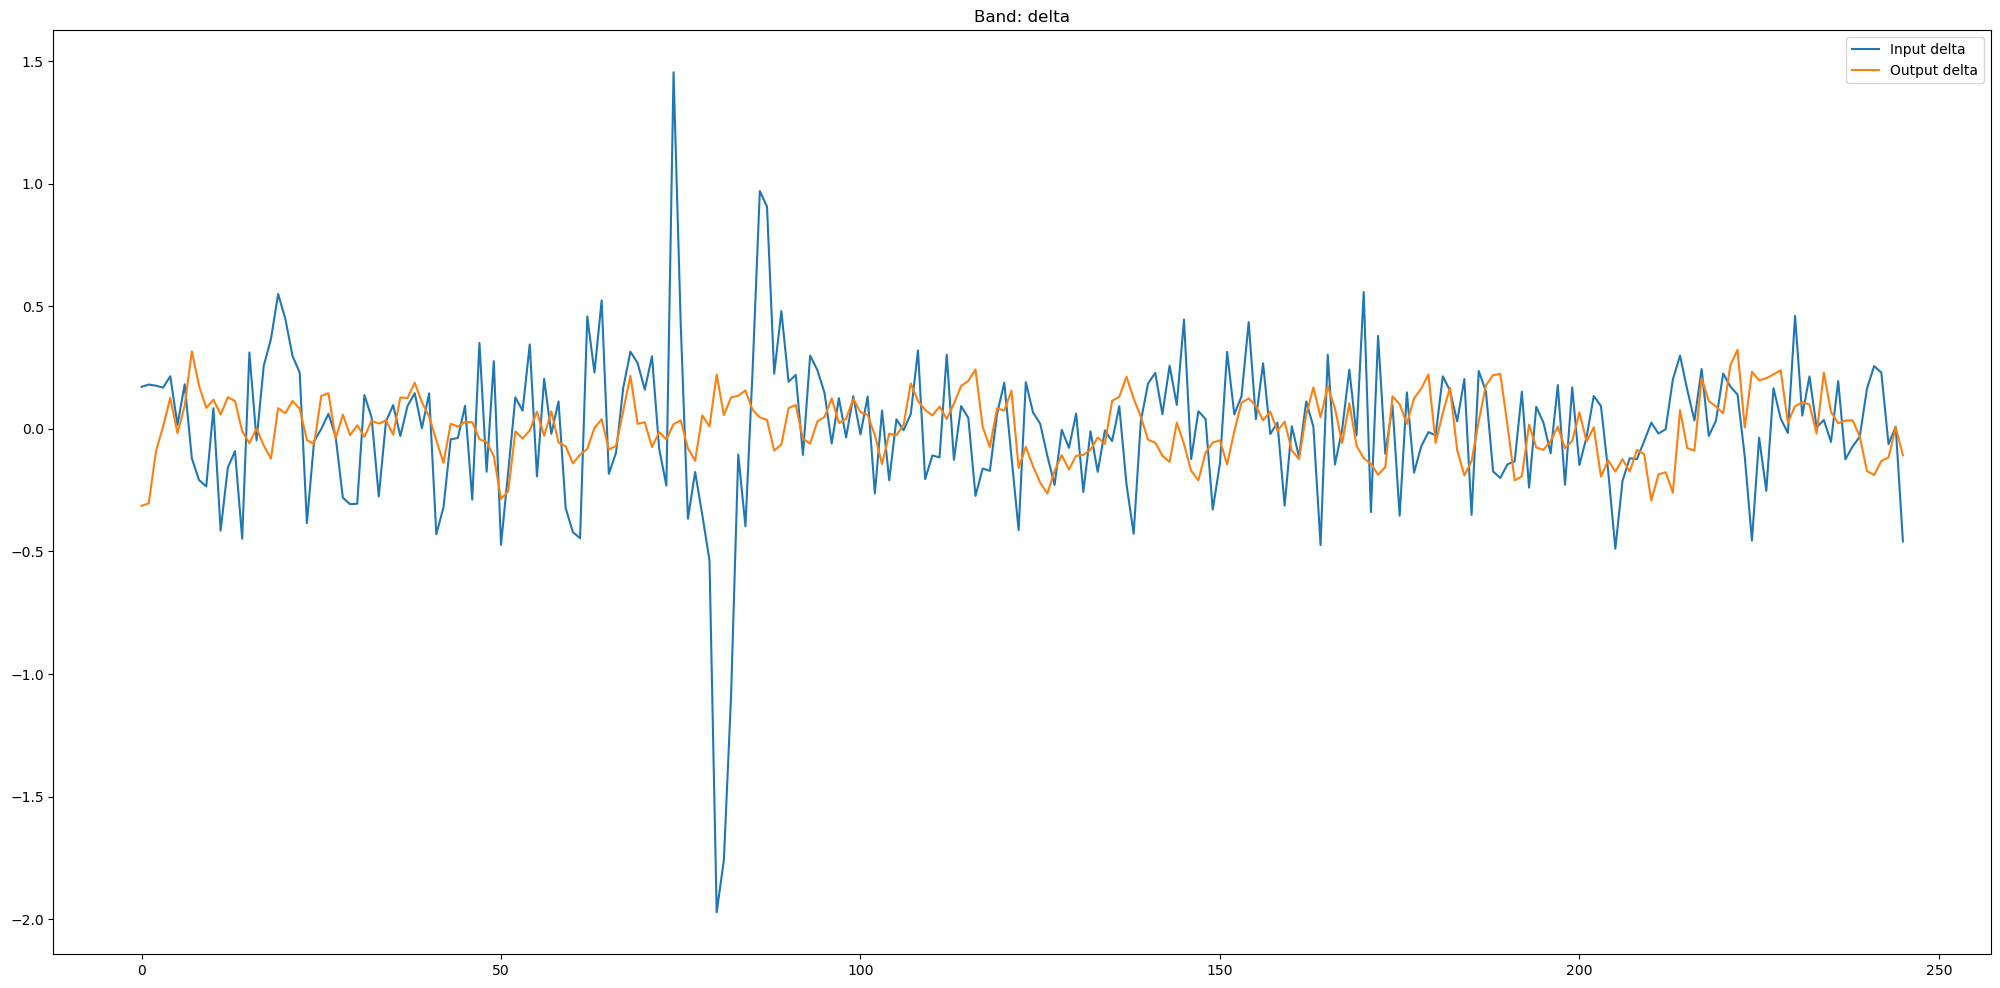

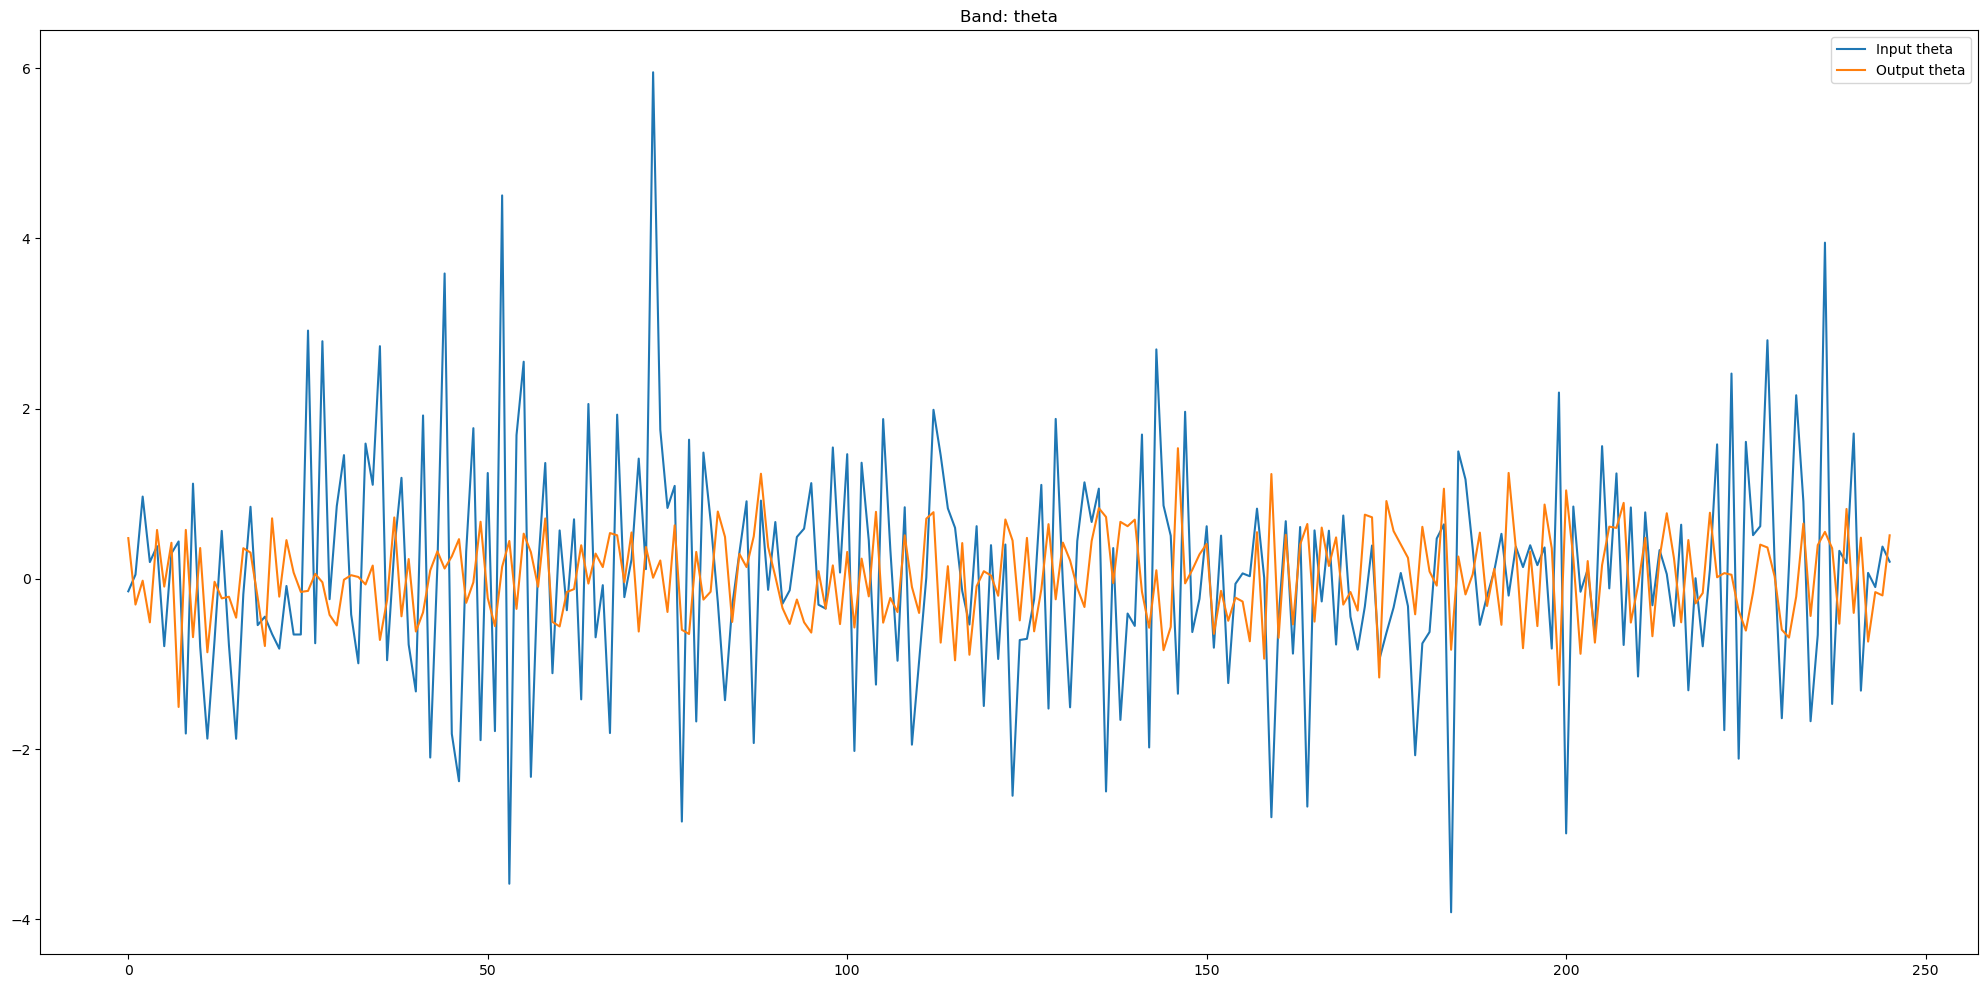

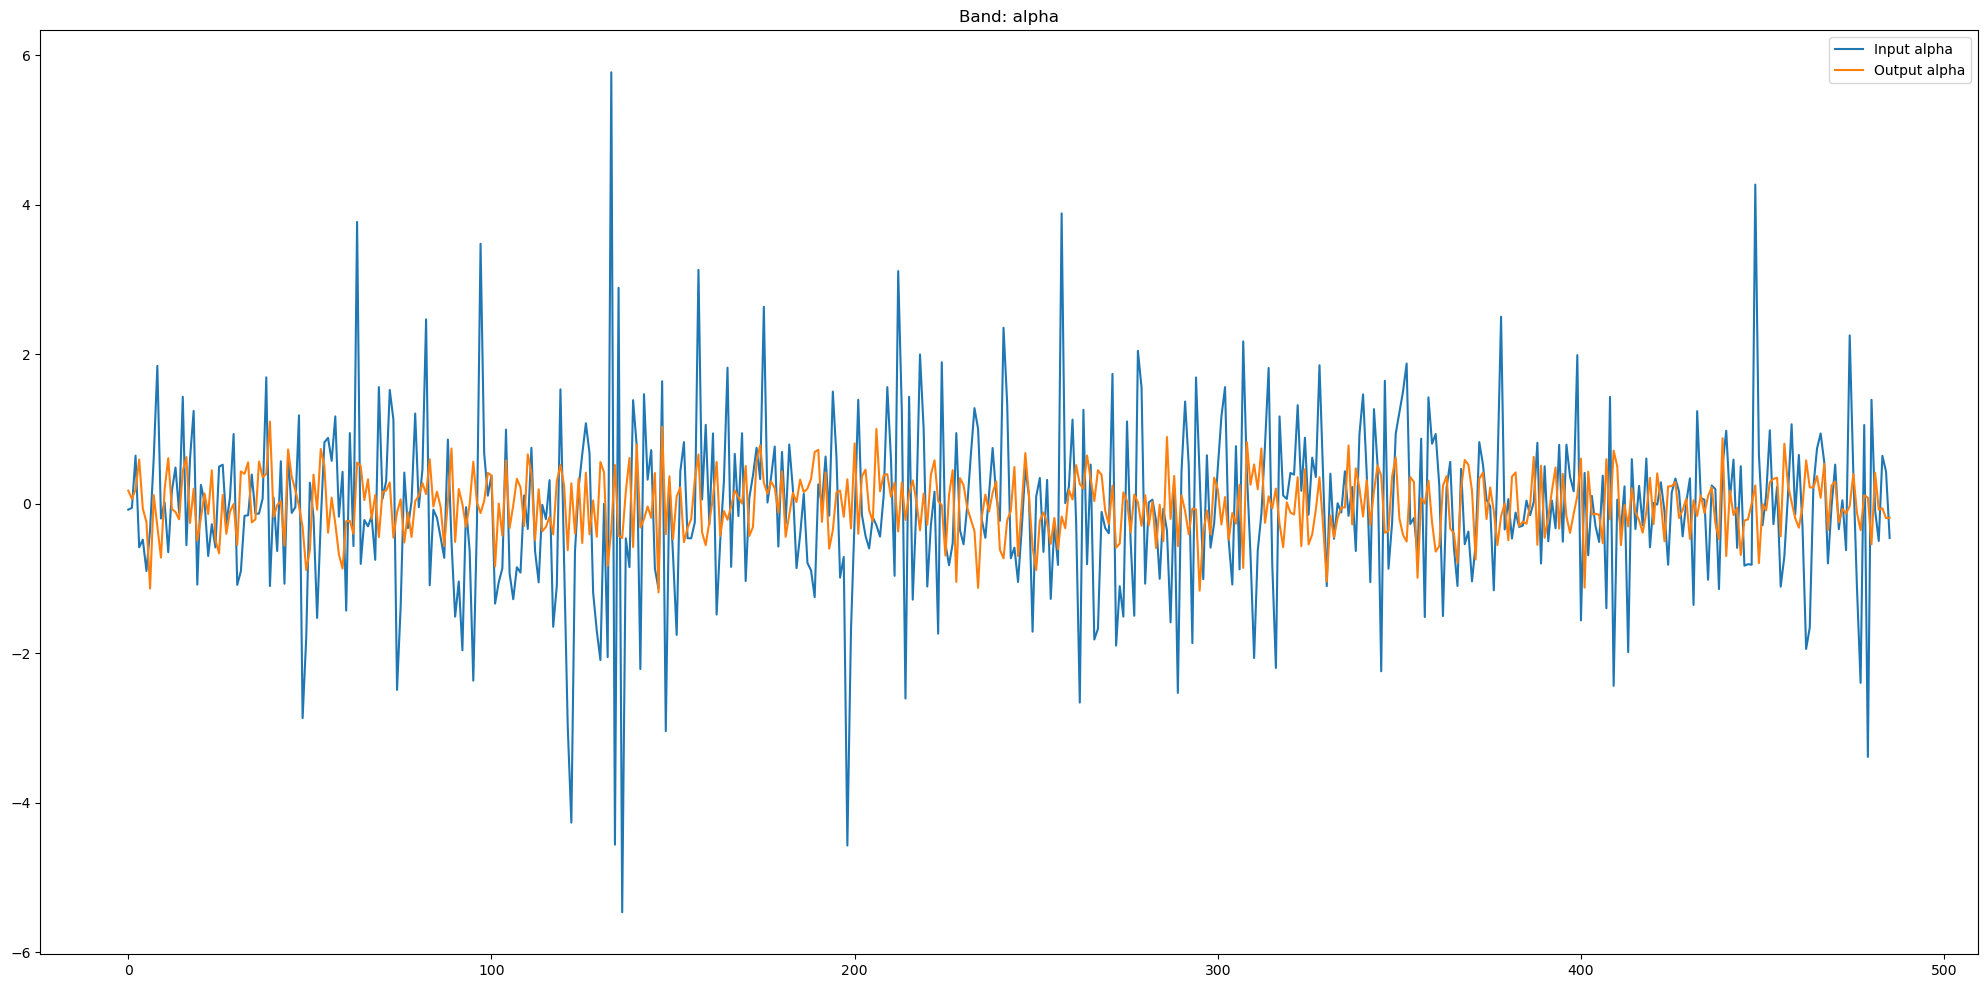

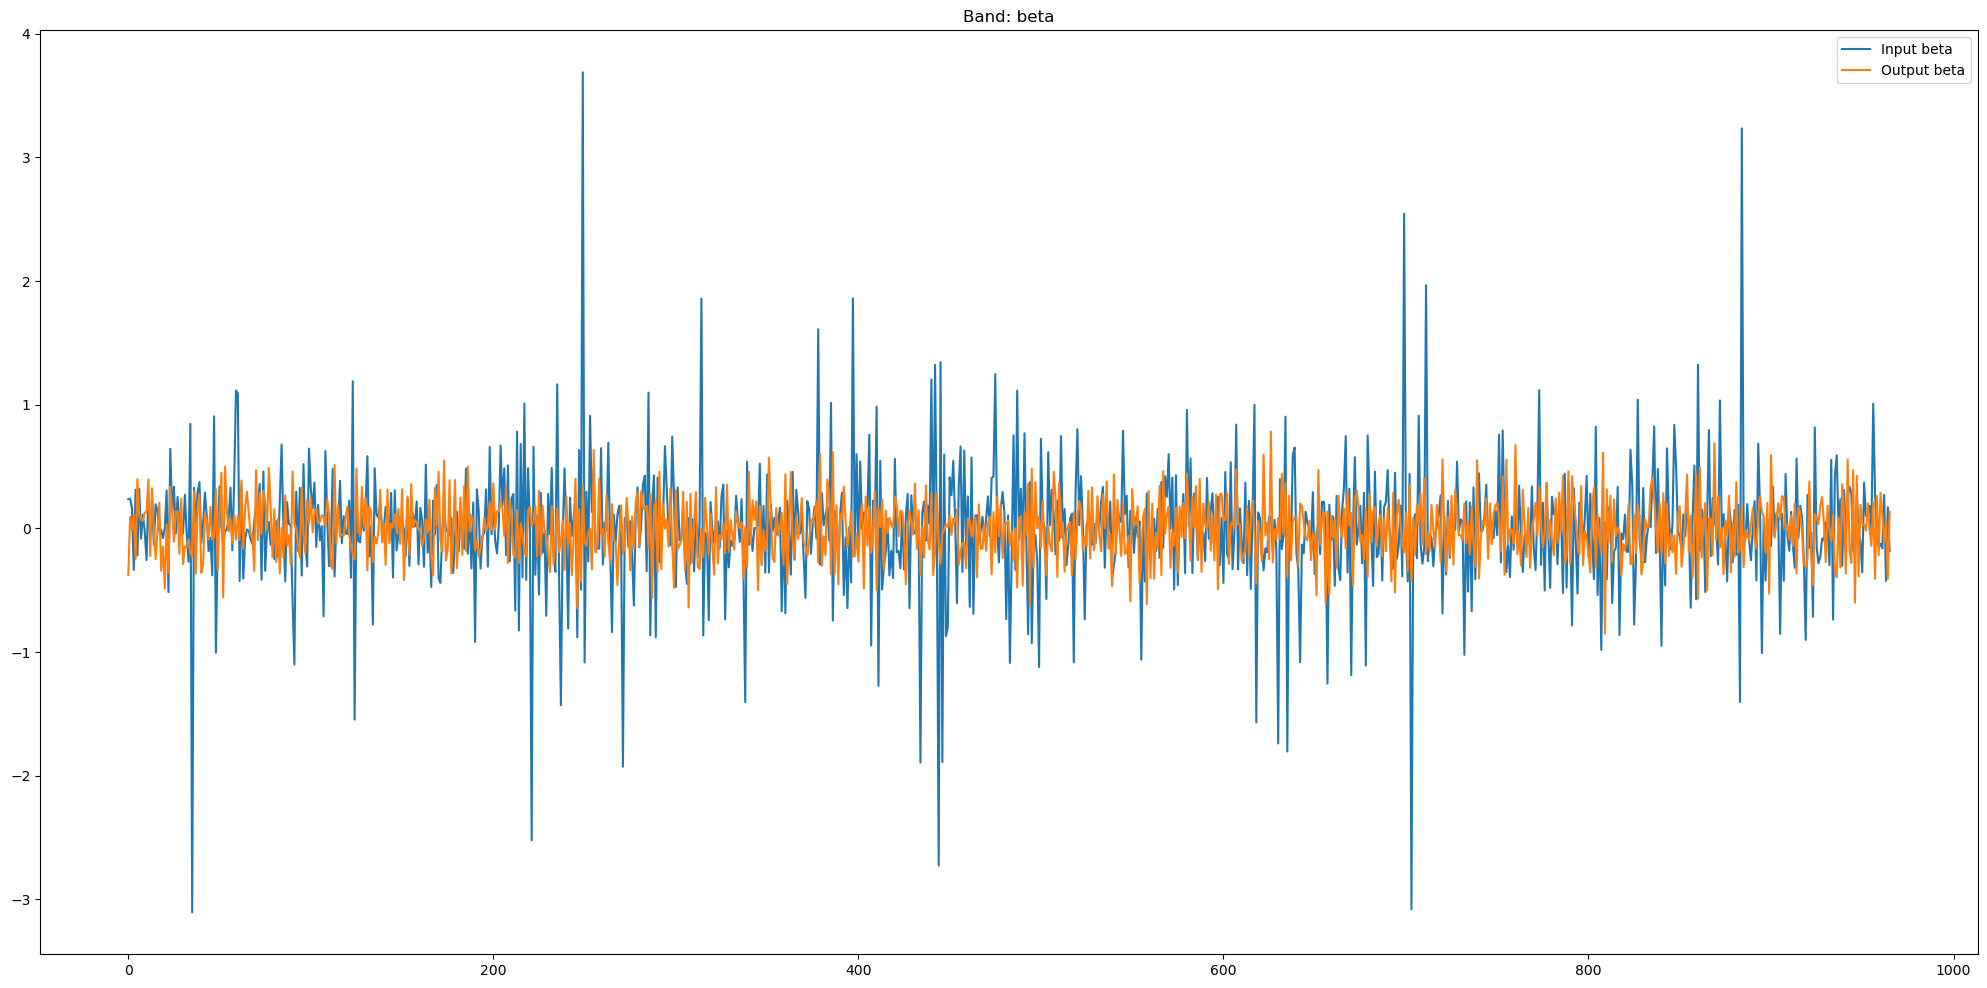

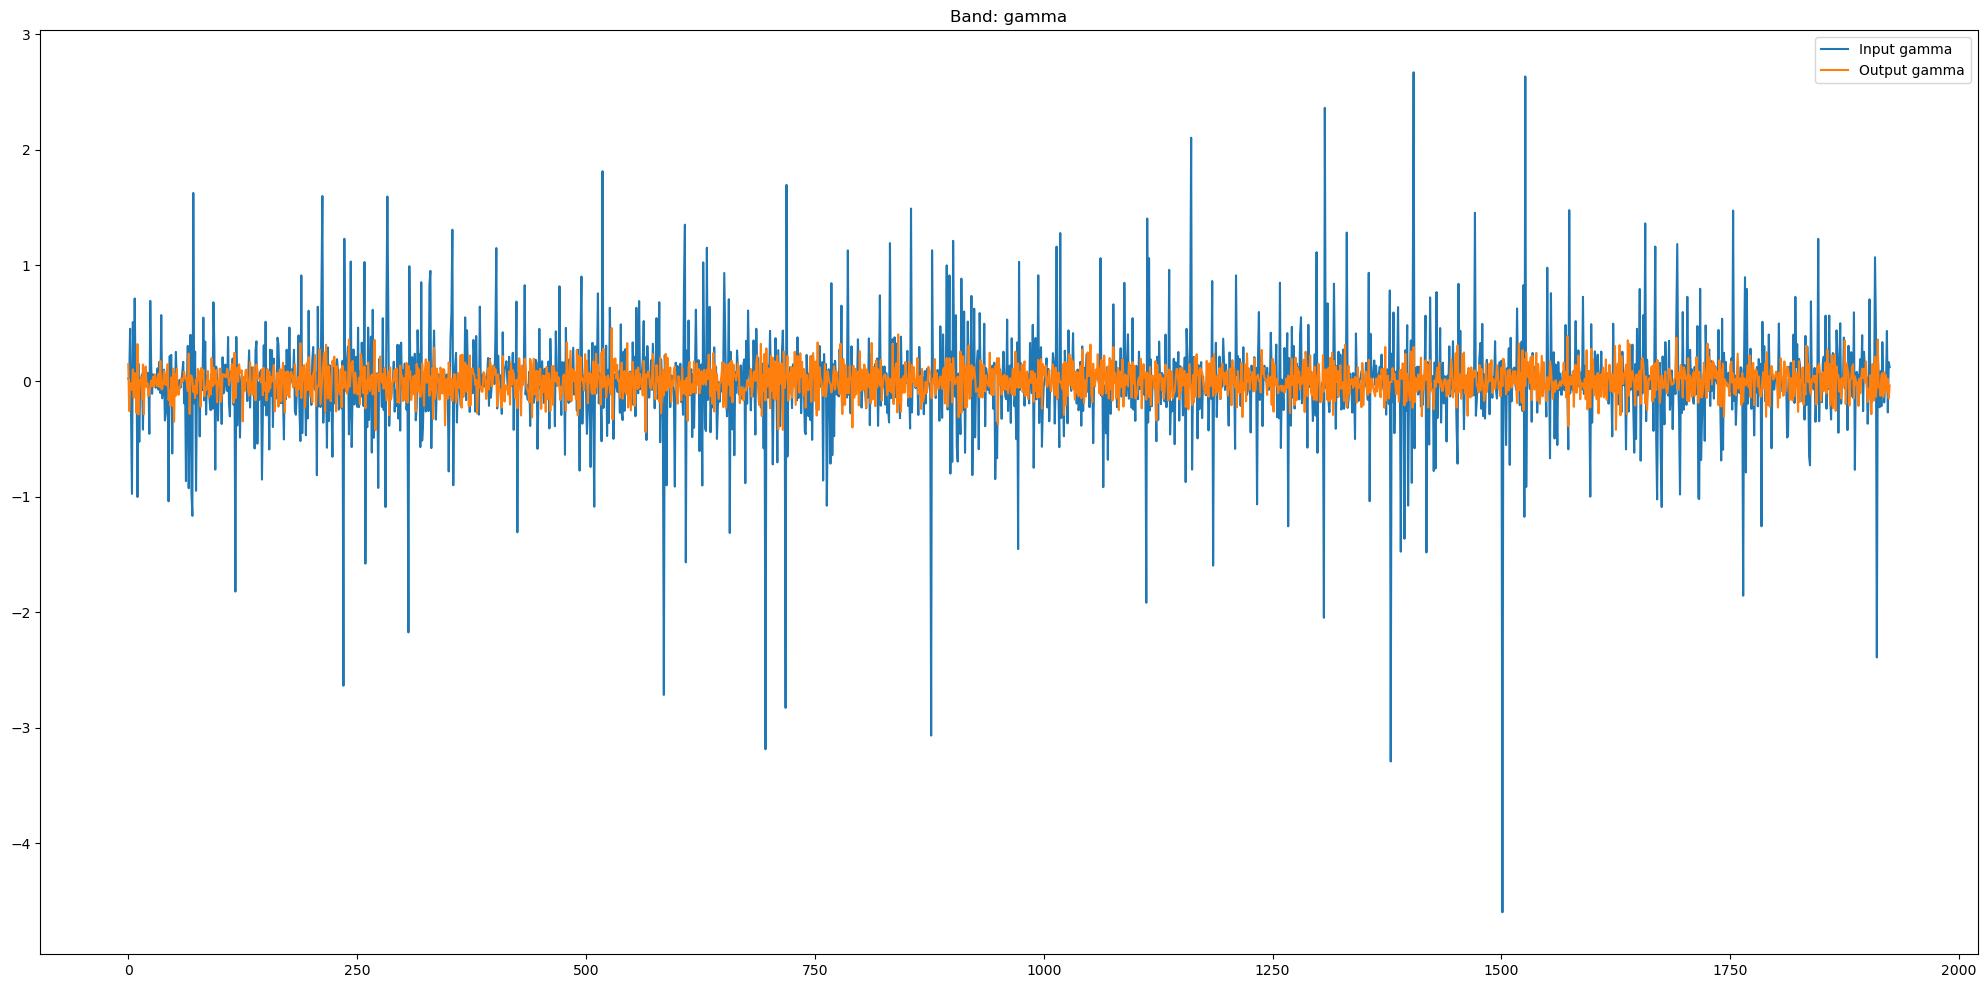

In [139]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][9,channel, :].cpu().detach().numpy(), label=f"Input {band}")
    #plt.plot(outputs[band][0][9, channel, :].cpu().detach().numpy(), label=f"Encoding {band}")
    plt.plot(outputs[band][1][9, channel, :].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()